# Introduction: Home Credit Default Risk

## Supervised Classification Task
This project is a **supervised learning** problem where the target variable is binary:
- `0`: the client will repay the loan on time.
- `1`: the client will have difficulty repaying the loan.

The objective is to train a model that can accurately classify future clients based on their application information.

---

# Data Overview

The dataset is provided by [Home Credit](http://www.homecredit.net/about-us.aspx), a financial institution focused on offering credit to individuals with little or no access to traditional banking services. Being able to predict whether a client is likely to default on a loan is crucial for the business, and this competition hosted on Kaggle invites the machine learning community to develop models to support that goal.

There are 7 main datasets included:

- **`application_train` / `application_test`**: Main datasets containing information about each loan application. Each row represents one loan, identified by `SK_ID_CURR`. The training set includes the `TARGET` variable.
- **`bureau`**: Previous credit information from other financial institutions. One application may correspond to multiple entries in this table.
- **`bureau_balance`**: Monthly-level balance information for credits listed in `bureau`.
- **`previous_application`**: Previous loan applications at Home Credit for clients listed in the current applications.
- **`POS_CASH_BALANCE`**: Monthly balance records for previous point-of-sale or cash loans provided by Home Credit.
- **`credit_card_balance`**: Monthly balance data for previous credit cards issued by Home Credit.
- **`installments_payment`**: Records of payment history for previous Home Credit loans, including both paid and missed payments.

The following diagram summarizes the relationships between the different data sources:

![Data Relationship Diagram](https://storage.googleapis.com/kaggle-media/competitions/home-credit/home_credit.png)

---

# Scope of This Notebook

For simplicity and interpretability, this notebook will focus only on the **main application training and testing datasets** (`application_train` and `application_test`) to build a baseline predictive model.

## 1. Import Libraries and Set Options

We import essential libraries such as `numpy`, `pandas`, `matplotlib`, `seaborn`, and machine learning tools from `sklearn`. We also suppress warnings and ensure that pandas displays all columns for easier exploration.

In [9]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", 200)

## 2. Load Data and Explore Target Variable

We read the training and testing datasets and visualize the distribution of the target variable. The dataset is imbalanced, with a majority of loans being repaid.

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


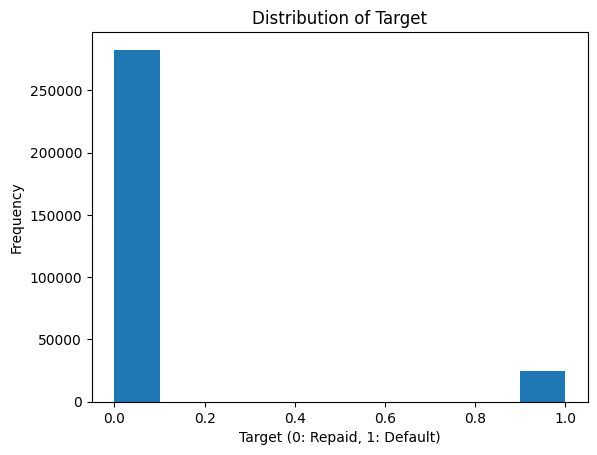

In [10]:
# Read in the data
app_train = pd.read_csv('/kaggle/input/rakamin/application_train.csv')
app_test = pd.read_csv('/kaggle/input/rakamin/application_test.csv')
bureau = pd.read_csv('/kaggle/input/rakamin/bureau.csv')

# Contoh agregasi (meskipun belum dipakai)
bureau_agg = bureau.groupby('SK_ID_CURR').last().reset_index()

# Distribusi target
print(app_train['TARGET'].value_counts(normalize=True) * 100)
app_train['TARGET'].astype(int).plot.hist(title='Distribution of Target')
plt.xlabel('Target (0: Repaid, 1: Default)')
plt.show()

## 3. Checking Missing Values and Data Types

We define a helper function to summarize missing values in the dataset. We also examine the data types and count the number of unique values in categorical features.

In [11]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table.columns = ['Missing Values', '% of Total Values']
    mis_val_table = mis_val_table[mis_val_table['Missing Values'] > 0]
    return mis_val_table.sort_values('% of Total Values', ascending=False).round(1)

print(missing_values_table(app_train).head(20))
print(app_train.dtypes.value_counts())
print(app_train.select_dtypes('object').apply(pd.Series.nunique, axis=0))


                          Missing Values  % of Total Values
COMMONAREA_MEDI                   214865               69.9
COMMONAREA_AVG                    214865               69.9
COMMONAREA_MODE                   214865               69.9
NONLIVINGAPARTMENTS_MEDI          213514               69.4
NONLIVINGAPARTMENTS_MODE          213514               69.4
NONLIVINGAPARTMENTS_AVG           213514               69.4
FONDKAPREMONT_MODE                210295               68.4
LIVINGAPARTMENTS_MODE             210199               68.4
LIVINGAPARTMENTS_MEDI             210199               68.4
LIVINGAPARTMENTS_AVG              210199               68.4
FLOORSMIN_MODE                    208642               67.8
FLOORSMIN_MEDI                    208642               67.8
FLOORSMIN_AVG                     208642               67.8
YEARS_BUILD_MODE                  204488               66.5
YEARS_BUILD_MEDI                  204488               66.5
YEARS_BUILD_AVG                   204488

## 4. Encoding Categorical Features

For categorical columns with only two unique values, we use Label Encoding. For other categorical features, we apply One-Hot Encoding. This ensures our models can work with categorical data properly.

In [12]:
le = LabelEncoder()
le_count = 0
for col in app_train:
    if app_train[col].dtype == 'object' and app_train[col].nunique() <= 2:
        le.fit(app_train[col])
        app_train[col] = le.transform(app_train[col])
        app_test[col] = le.transform(app_test[col])
        le_count += 1
print(f'{le_count} columns were label encoded.')

# One-hot encoding
app_train = pd.get_dummies(app_train)
app_test = pd.get_dummies(app_test)

print('Training Features shape:', app_train.shape)
print('Testing Features shape:', app_test.shape)


4 columns were label encoded.
Training Features shape: (307511, 242)
Testing Features shape: (48744, 238)


## 5. Align Columns and Handle Anomalies

We align the training and testing data so they contain the same columns. We also identify and handle a known anomaly in the `DAYS_EMPLOYED` column, where the value 365243 represents a missing value.

In [13]:
# Simpan label
train_labels = app_train['TARGET']
app_train, app_test = app_train.align(app_test, join='inner', axis=1)
app_train['TARGET'] = train_labels

# Tangani nilai anomali
for df in [app_train, app_test]:
    df['DAYS_EMPLOYED_ANOM'] = df['DAYS_EMPLOYED'] == 365243
    df['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)


## 6. Visualizing Age and External Source Correlations

We explore how age relates to loan repayment and visualize the distribution of external source features (`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`). These features are highly correlated with the target.

Korelasi DAYS_BIRTH dan TARGET: -0.07823930830982712


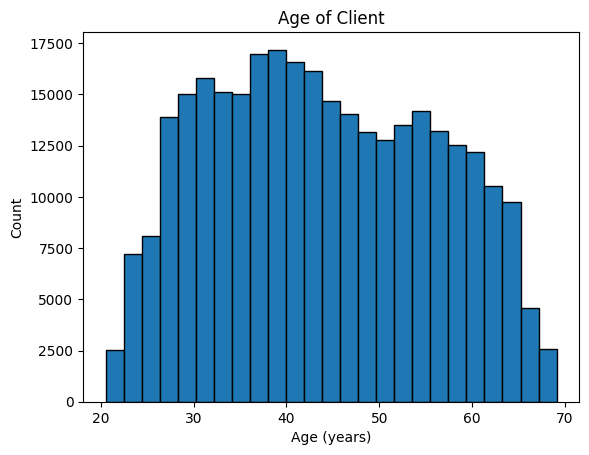

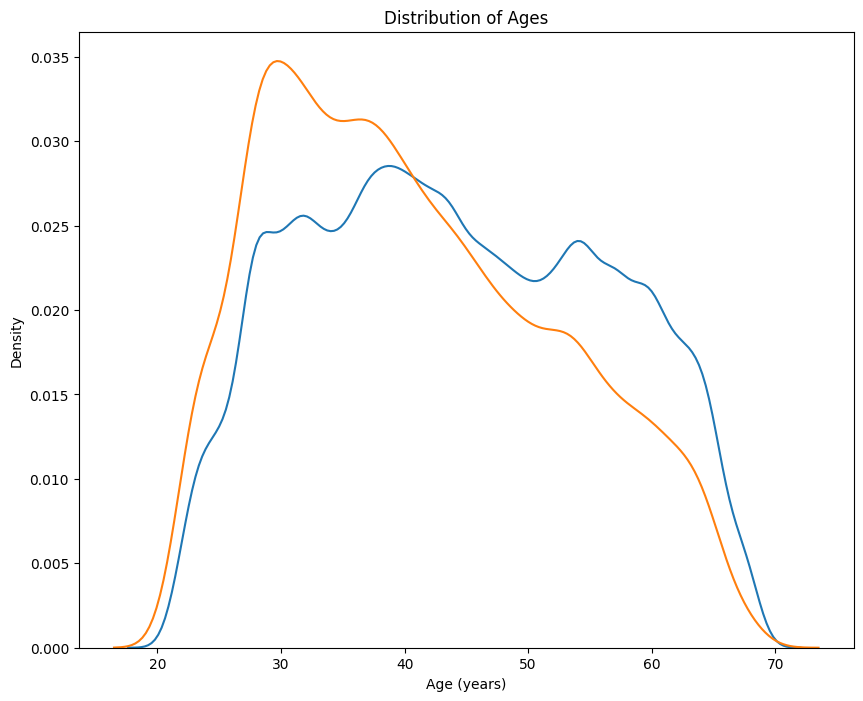

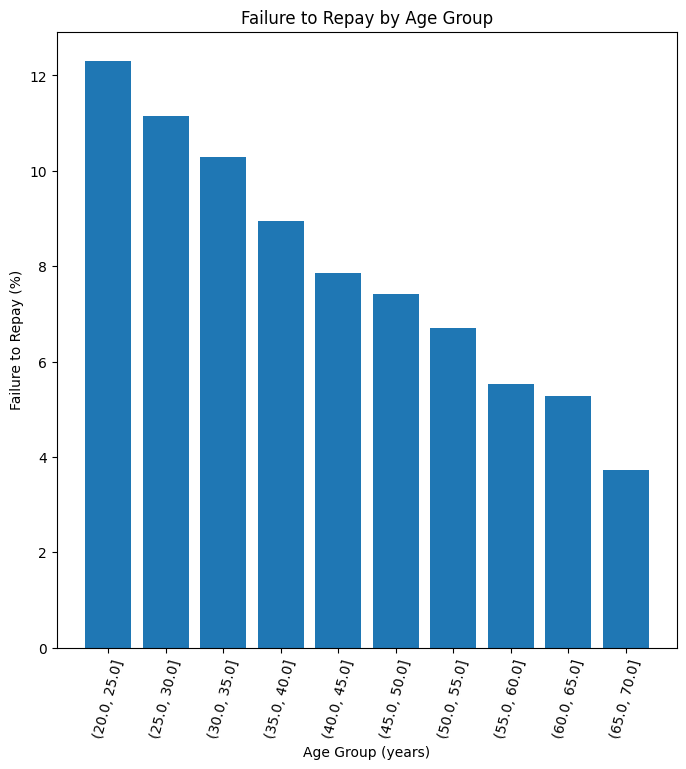

In [14]:
# Konversi umur jadi positif
app_train['DAYS_BIRTH'] = abs(app_train['DAYS_BIRTH'])

# Korelasi umur dan target
print("Korelasi DAYS_BIRTH dan TARGET:", app_train['DAYS_BIRTH'].corr(app_train['TARGET']))

# Histogram umur
plt.hist(app_train['DAYS_BIRTH'] / 365, edgecolor='k', bins=25)
plt.title('Age of Client')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.show()

# KDE umur untuk masing-masing target
plt.figure(figsize=(10, 8))
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'DAYS_BIRTH'] / 365, label='target == 0')
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'DAYS_BIRTH'] / 365, label='target == 1')
plt.xlabel('Age (years)')
plt.ylabel('Density')
plt.title('Distribution of Ages')
plt.show()

# Binning umur
age_data = app_train[['TARGET', 'DAYS_BIRTH']].copy()
age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH'] / 365
age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins=np.linspace(20, 70, num=11))
age_groups = age_data.groupby('YEARS_BINNED').mean()

# Plot kegagalan bayar berdasarkan usia
plt.figure(figsize=(8, 8))
plt.bar(age_groups.index.astype(str), 100 * age_groups['TARGET'])
plt.xticks(rotation=75)
plt.xlabel('Age Group (years)')
plt.ylabel('Failure to Repay (%)')
plt.title('Failure to Repay by Age Group')
plt.show()

                TARGET  EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3  DAYS_BIRTH
TARGET        1.000000     -0.155317     -0.160472     -0.178919   -0.078239
EXT_SOURCE_1 -0.155317      1.000000      0.213982      0.186846    0.600610
EXT_SOURCE_2 -0.160472      0.213982      1.000000      0.109167    0.091996
EXT_SOURCE_3 -0.178919      0.186846      0.109167      1.000000    0.205478
DAYS_BIRTH   -0.078239      0.600610      0.091996      0.205478    1.000000


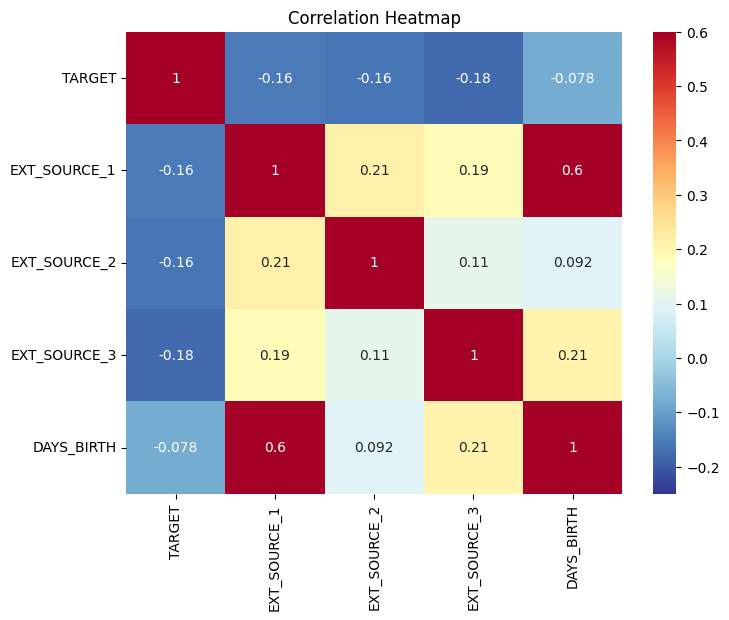

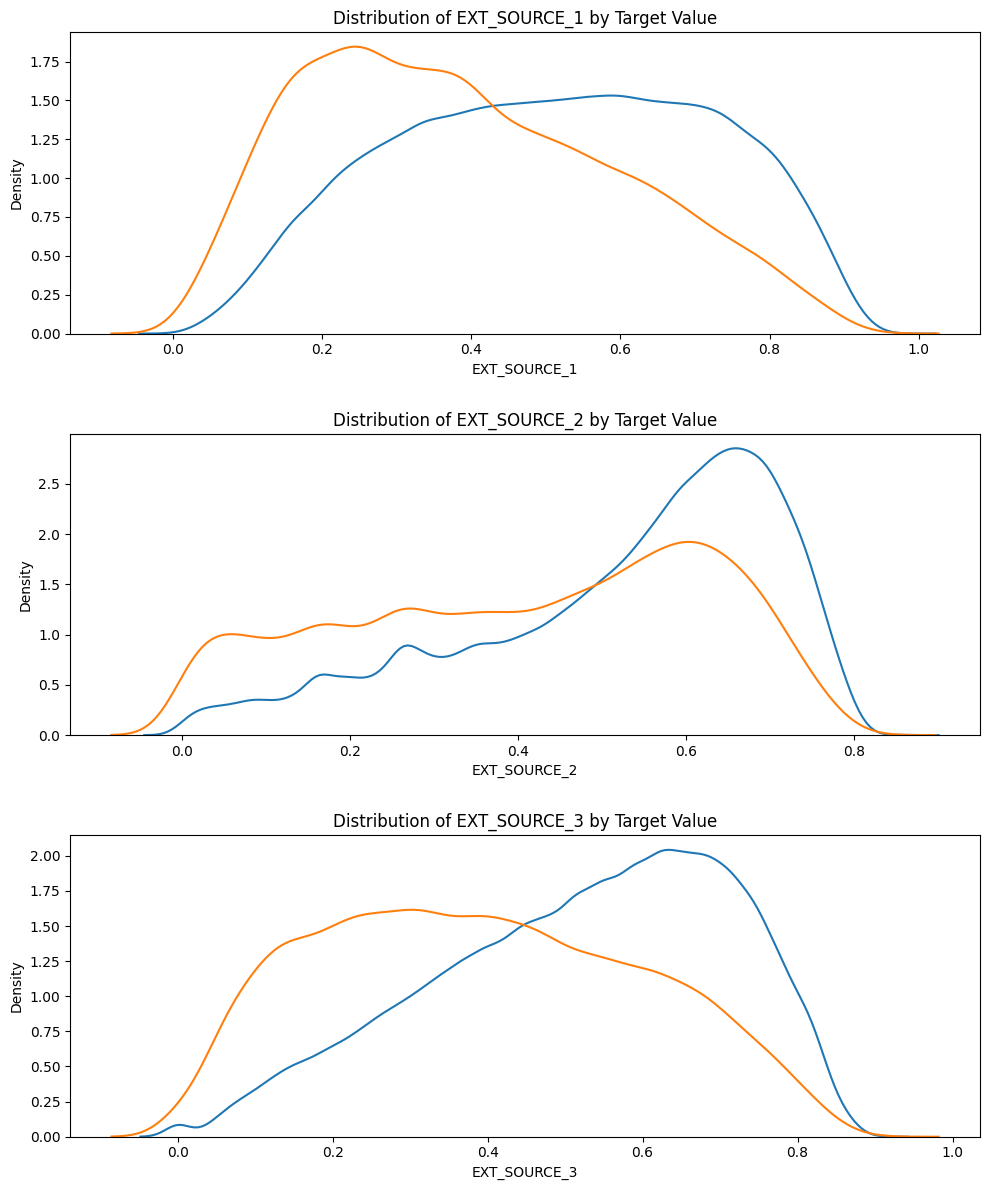

In [15]:
ext_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_data_corrs = ext_data.corr()
print(ext_data_corrs)

plt.figure(figsize=(8, 6))
sns.heatmap(ext_data_corrs, cmap=plt.cm.RdYlBu_r, vmin=-0.25, vmax=0.6, annot=True)
plt.title('Correlation Heatmap')
plt.show()

# KDE plot EXT_SOURCE
plt.figure(figsize=(10, 12))
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    plt.subplot(3, 1, i + 1)
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, source], label='target == 0')
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, source], label='target == 1')
    plt.title(f'Distribution of {source} by Target Value')
    plt.xlabel(source)
    plt.ylabel('Density')
plt.tight_layout(h_pad=2.5)
plt.show()


## 7. Feature Engineering

We create several domain-specific features such as `CREDIT_INCOME_PERCENT`, `ANNUITY_INCOME_PERCENT`, `CREDIT_TERM`, and `DAYS_EMPLOYED_PERCENT` to capture more meaningful patterns in the data.

In [16]:
def add_domain_features(df):
    df['CREDIT_INCOME_PERCENT'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
    df['ANNUITY_INCOME_PERCENT'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    df['CREDIT_TERM'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']
    df['DAYS_EMPLOYED_PERCENT'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
    return df

app_train = add_domain_features(app_train)
app_test = add_domain_features(app_test)

## 8. Logistic Regression (Baseline Model)

We train a simple Logistic Regression model using only complete cases (rows without missing values). This serves as a baseline to compare with more complex models later.

In [17]:
app_train2 = app_train.dropna()
X_lr = app_train2.drop(columns=['TARGET'])
y_lr = app_train2['TARGET']

x_train_lr, x_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.25, random_state=2023)

log_reg = LogisticRegression(C=0.0001, random_state=42)
log_reg.fit(x_train_lr, y_train_lr)

print("Logistic Regression AUC (train):", roc_auc_score(y_train_lr, log_reg.predict_proba(x_train_lr)[:, 1]))
print("Logistic Regression AUC (test):", roc_auc_score(y_test_lr, log_reg.predict_proba(x_test_lr)[:, 1]))

Logistic Regression AUC (train): 0.6138367832269649
Logistic Regression AUC (test): 0.6010122611919019


## 9. Random Forest Model

We train a more powerful Random Forest classifier. Before training, we handle missing values with median imputation and scale the features using Min-Max scaling.

In [18]:
features_rf = app_train.drop(columns=['TARGET', 'SK_ID_CURR'])
labels_rf = app_train['TARGET']
x_test_rf = app_test.drop(columns=['SK_ID_CURR'])
sk_id_curr_test = app_test['SK_ID_CURR'].copy()

x_train_rf, x_valid_rf, y_train_rf, y_valid_rf = train_test_split(features_rf, labels_rf, test_size=0.25, random_state=2023)

# Imputasi dan scaling
imputer = SimpleImputer(strategy='median')
scaler = MinMaxScaler()

x_train_rf_scaled = scaler.fit_transform(imputer.fit_transform(x_train_rf))
x_valid_rf_scaled = scaler.transform(imputer.transform(x_valid_rf))
x_test_rf_scaled = scaler.transform(imputer.transform(x_test_rf))

random_forest = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=1)
random_forest.fit(x_train_rf_scaled, y_train_rf)

print("Random Forest ROC AUC (Train):", roc_auc_score(y_train_rf, random_forest.predict_proba(x_train_rf_scaled)[:, 1]))
print("Random Forest ROC AUC (Valid):", roc_auc_score(y_valid_rf, random_forest.predict_proba(x_valid_rf_scaled)[:, 1]))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   25.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   58.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    4.6s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


Random Forest ROC AUC (Train): 1.0


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.6s


Random Forest ROC AUC (Valid): 0.7090365792828005


[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    1.4s finished


## 10. Create Submission File

We generate the submission file by predicting the probability of default on the test dataset using the trained Random Forest model.

In [19]:
submission = pd.DataFrame({
    'SK_ID_CURR': sk_id_curr_test,
    'TARGET': random_forest.predict_proba(x_test_rf_scaled)[:, 1]
})
submission.to_csv('/kaggle/working/random_forest_submission.csv', index=False)
print("✅ Submission file saved as 'random_forest_submission.csv'")

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s


✅ Submission file saved as 'random_forest_submission.csv'


[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.8s finished


## 11. Feature Importance

To understand what features were most influential in the model’s decision, we plot the top 15 features based on importance scores from the Random Forest model.

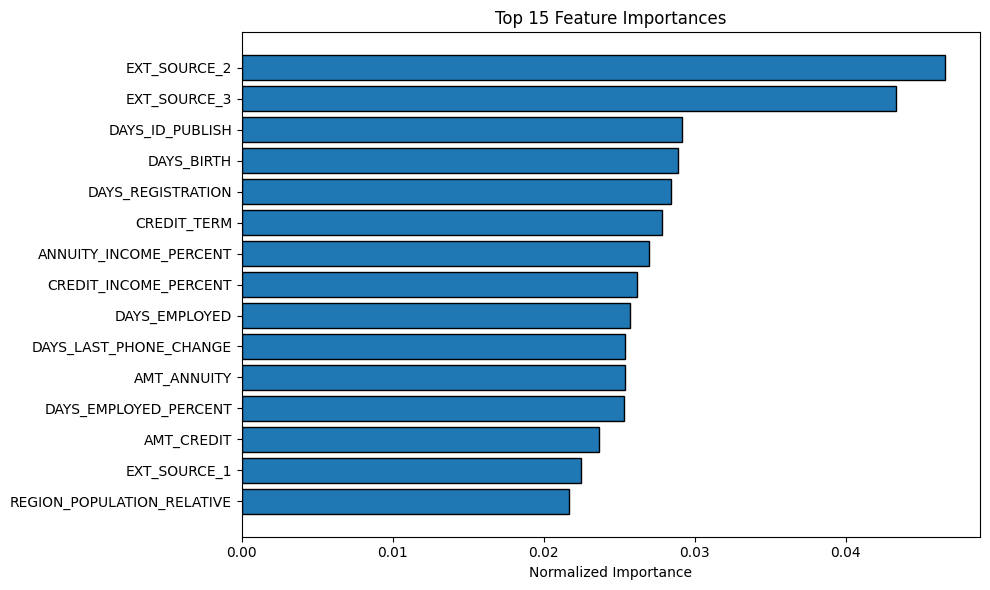

In [20]:
feature_importances = pd.DataFrame({
    'feature': x_train_rf.columns,
    'importance': random_forest.feature_importances_
}).sort_values(by='importance', ascending=False)

def plot_feature_importances(df):
    df = df.sort_values('importance', ascending=False).reset_index(drop=True)
    df['importance_normalized'] = df['importance'] / df['importance'].sum()

    plt.figure(figsize=(10, 6))
    ax = plt.subplot()
    ax.barh(list(reversed(list(df.index[:15]))),
            df['importance_normalized'].head(15),
            align='center', edgecolor='k')
    ax.set_yticks(list(reversed(list(df.index[:15]))))
    ax.set_yticklabels(df['feature'].head(15))
    plt.xlabel('Normalized Importance')
    plt.title('Top 15 Feature Importances')
    plt.tight_layout()
    plt.show()

plot_feature_importances(feature_importances)